In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from kmodes.kprototypes import KPrototypes

In [78]:
# Load data
cards_df = pd.read_csv('./data/cards_cleaned.csv').fillna(0)
cards_df

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Royal Delivery,28000018,normal,3.0,common,437.0,787.0,spell,ground,both,splash,False,4.00,54.17
116,Void,28000023,normal,3.0,epic,1020.0,0.0,spell,ground,both,splash,False,0.80,53.83
117,Goblin Curse,28000024,normal,2.0,epic,210.0,0.0,spell,ground,both,splash,False,1.28,52.53
118,Spirit Empress,28000025,normal,6.0,legendary,307.0,1177.0,troop,flying,both,single,False,4.80,54.23


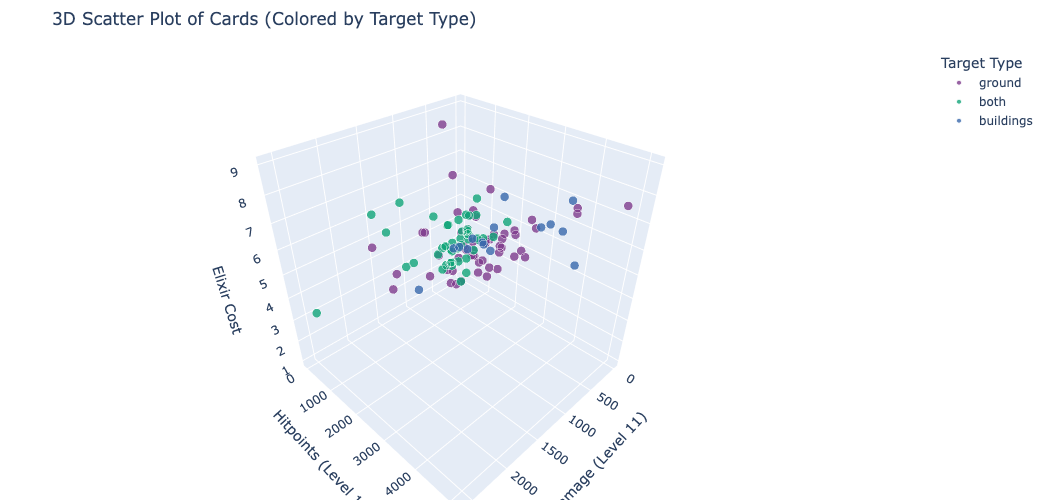

In [79]:
# Interactive 3D scatterplot of numerical data, color-coded by its target type. Can toggle which datapoints to view by their target type via clicking on the legend.
fig = px.scatter_3d(
    cards_df,
    x='damage11',
    y='hitpoints11',
    z='elixirCost',
    color='targets',
    hover_name='name',
    hover_data=[
        'type',
        'rarity',
        'elixirCost',
    ],
    labels={
        'elixirCost': 'Elixir Cost',
        'damage11': 'Damage (Level 11)',
        'hitpoints11': 'Hitpoints (Level 11)',
        'targets': 'Target Type',
    },
    title='3D Scatter Plot of Cards (Colored by Target Type)',
    color_discrete_sequence=px.colors.qualitative.Bold,
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.8,
        line=dict(
            width=1, color='white'
        )
    )
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50), width=1000, height=500)
#fig.write_html('./graphs/3d_scatter_plot_of_cards.html')
fig.show()

# all cards appear to be above the z=x+y plane

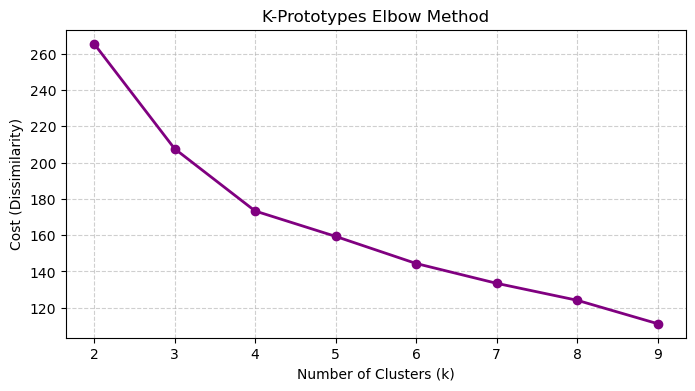

In [80]:
# Use K-prototypes instead of K-means for mixed data
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11']
categorical_cols = ['wild', 'rarity', 'type', 'mobility', 'targets', 'attack_type', 'groupCard']

troops_clustering_df = cards_df.loc[cards_df['type']=='troop', numerical_cols + categorical_cols].copy()
scaler = StandardScaler()
troops_clustering_df[numerical_cols] = scaler.fit_transform(troops_clustering_df[numerical_cols])

clustering_matrix = troops_clustering_df.to_numpy()
cat_indices = [troops_clustering_df.columns.get_loc(col) for col in categorical_cols]

costs = []
k_range = range(2, 10)

for k in k_range:
    kproto = KPrototypes(n_clusters=k, init="Cao", random_state=67, n_init=5)
    kproto.fit(clustering_matrix, categorical=cat_indices)
    costs.append(kproto.cost_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, costs, marker="o", color="purple", linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost (Dissimilarity)")
plt.title("K-Prototypes Elbow Method")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [81]:
# Fit optimal k
optimal_k = 4
kproto_final = KPrototypes(
    n_clusters=optimal_k, init="Cao", random_state=4, n_init=5
)

labels = kproto_final.fit_predict(clustering_matrix, categorical=cat_indices)
troops_clustered_df = cards_df.loc[cards_df['type']=='troop'].copy()
troops_clustered_df["Cluster"] = labels
troops_clustered_df = troops_clustered_df.sort_values(by="Cluster")

troops_clustered_df

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate,Cluster
43,Elite Barbarians,26000043,normal,6.0,common,726.0,1341.0,troop,ground,ground,single,True,3.28,52.40,0
44,Hunter,26000044,evo,4.0,epic,848.0,885.0,troop,ground,both,single,False,1.52,50.58,0
58,Wall Breakers,26000058,evo,2.0,epic,962.0,330.0,troop,ground,buildings,single,True,7.12,54.09,0
18,Mini P.E.K.K.A,26000018,hero,4.0,rare,720.0,1361.0,troop,ground,ground,single,False,7.36,51.32,0
27,Dark Prince,26000027,normal,4.0,epic,1240.0,1440.0,troop,ground,ground,single,False,4.24,56.87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38,Ice Golem,26000038,hero,2.0,rare,84.0,1198.0,troop,ground,ground,single,False,4.08,51.08,3
39,Mega Minion,26000039,hero,3.0,rare,311.0,837.0,troop,flying,both,single,False,3.28,58.08,3
113,Heal Spirit,28000016,normal,1.0,rare,110.0,230.0,troop,ground,both,splash,False,1.60,59.30,3
10,Skeletons,26000010,evo,1.0,common,243.0,81.0,troop,ground,ground,single,True,14.56,51.05,3


In [82]:
# Merge with spells and buildings
clustered_df = pd.concat([troops_clustered_df, cards_df.loc[cards_df['type']!='troop']])
clustered_df.loc[clustered_df['type']=='building', 'Cluster'] = optimal_k
clustered_df.loc[clustered_df['type']=='spell', 'Cluster'] = optimal_k+1
clustered_df['Cluster'] = clustered_df['Cluster'].astype(int).astype(str)
clustered_df.to_csv('./data/cards_clustered.csv', index=False)
clustered_df

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate,Cluster
43,Elite Barbarians,26000043,normal,6.0,common,726.0,1341.0,troop,ground,ground,single,True,3.28,52.40,0
44,Hunter,26000044,evo,4.0,epic,848.0,885.0,troop,ground,both,single,False,1.52,50.58,0
58,Wall Breakers,26000058,evo,2.0,epic,962.0,330.0,troop,ground,buildings,single,True,7.12,54.09,0
18,Mini P.E.K.K.A,26000018,hero,4.0,rare,720.0,1361.0,troop,ground,ground,single,False,7.36,51.32,0
27,Dark Prince,26000027,normal,4.0,epic,1240.0,1440.0,troop,ground,ground,single,False,4.24,56.87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,Giant Snowball,28000017,evo,2.0,common,192.0,0.0,spell,ground,both,splash,False,2.24,53.08,5
115,Royal Delivery,28000018,normal,3.0,common,437.0,787.0,spell,ground,both,splash,False,4.00,54.17,5
116,Void,28000023,normal,3.0,epic,1020.0,0.0,spell,ground,both,splash,False,0.80,53.83,5
117,Goblin Curse,28000024,normal,2.0,epic,210.0,0.0,spell,ground,both,splash,False,1.28,52.53,5


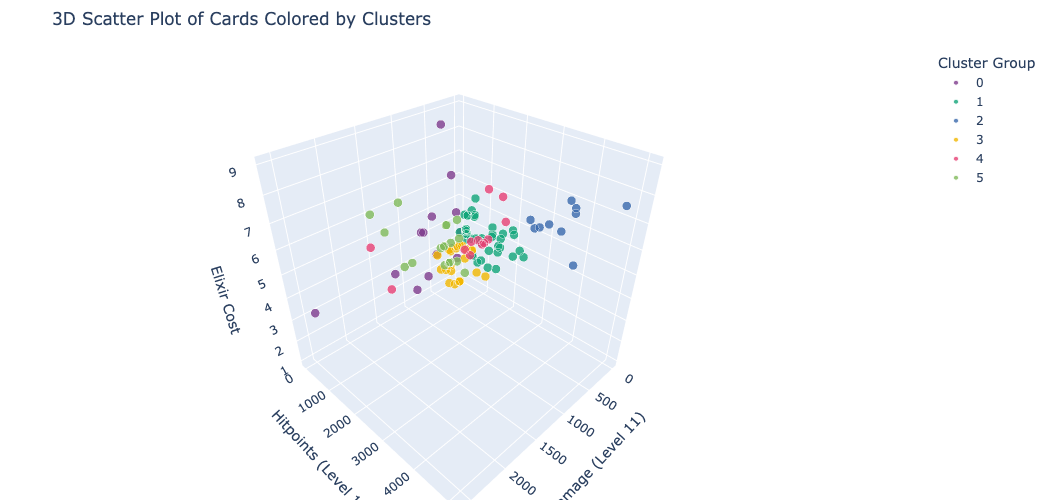

In [83]:
# Plot the clusters
fig = px.scatter_3d(
    clustered_df,
    x="damage11",
    y="hitpoints11",
    z="elixirCost",
    color="Cluster",
    hover_name="name",
    hover_data=[
        "type",
        "rarity",
        "targets",
        "Cluster",
    ],
    labels={
        "elixirCost": "Elixir Cost",
        "damage11": "Damage (Level 11)",
        "hitpoints11": "Hitpoints (Level 11)",
        "Cluster": "Cluster Group",
    },
    title="3D Scatter Plot of Cards Colored by Clusters",
    color_discrete_sequence=px.colors.qualitative.Bold,
)

fig.update_traces(
    marker=dict(
        size=5, opacity=0.8, line=dict(width=1, color="white")
    )
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50), width=1000, height=500)
#fig.write_html('./graphs/3d_scatter_plot_of_card_clusters.html')
fig.show()